(ต่อ) จาก cleansing data เสร็จ

# Feature Engineering : การเตรียมตัวแปรให้พร้อม

เป้าหมาย: สร้าง "อาวุธ" ใหม่ๆ ให้โมเดล หรือปรับรูปทรงข้อมูลให้โมเดลเข้าใจง่ายขึ้น

สิ่งที่ทำ:

* สร้างตัวแปรใหม่: เช่น แตกข้อมูลวันที่ออกมาเป็น "ชั่วโมง", "วันในสัปดาห์", "เดือน"

* Cyclic Transformation: แปลงเวลาให้เป็นค่า Sin/Cos เพื่อให้โมเดลเข้าใจว่า 23.59 น. กับ 00.01 น. คือเวลาที่ใกล้กัน

* Grouping: ยุบรวมข้อมูลที่มีความหลากหลายเกินไป เช่น ถ้ารัฐ (State) มีเยอะเกินไป ก็รวมกลุ่มรัฐที่เกิดอุบัติเหตุน้อยๆ เข้าด้วยกันเป็นกลุ่ม "Other"

Cell 1: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# โหลดข้อมูลที่ผ่านการ Clean มาจากไฟล์ 02
with tqdm(total=1, desc="Loading Data") as pbar:
    df = pd.read_parquet("../data/processed/accidents_clean.parquet")
    pbar.update(1)

Loading Data: 100%|██████████| 1/1 [00:01<00:00,  1.53s/it]


Cell 2: Mathematical Transformations (Log & Cyclical Time)
การทำ Log เพื่อลดความเบ้ และ Sin/Cos เพื่อบอกความเป็นวงกลมของเวลา

In [2]:
# 1. ลดความเบ้ของข้อมูลระยะทางและระยะเวลา
df['Log_Distance'] = np.log1p(df['Distance(mi)'])
df['Log_Duration'] = np.log1p(df['Accident_Duration_Min'].clip(lower=0))

# 2. แปลงเวลา (Hour/Month) เป็นวงกลม
df['Hour_sin'] = np.sin(2 * np.pi * df['Start_Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Start_Hour'] / 24)
df['Month_sin'] = np.sin(2 * np.pi * df['Start_Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Start_Month'] / 12)

Cell 4: Text Mining (Critical Description)
สกัด Insight จากข้อความเพื่อแยก Severity 4 (จุดที่สำคัญที่สุด)

In [3]:
# ค้นหาคำสำคัญที่บ่งบอกความรุนแรงสูง
critical_keywords = ['fatal', 'closed', 'blocked', 'multi-vehicle', 'severe', 'life-threatening']
pattern = '|'.join(critical_keywords)
df['Is_Critical_Description'] = df['Description'].str.contains(pattern, case=False, na=False).astype(int)

Cell 5: Feature Verification (Check correlations)
ตรวจดูว่าฟีเจอร์ที่สร้างใหม่ สัมพันธ์กับ Severity จริงไหม (Insight Check)

In [4]:
# --- รันส่วนนี้ก่อน เพื่อสร้าง Area_Density_Level ---

# 1. สร้าง Binning เพื่อระบุกลุ่มพื้นที่ (Grid)
df['Lat_bin'] = df['Start_Lat'].round(1)
df['Lng_bin'] = df['Start_Lng'].round(1)

# 2. คำนวณความหนาแน่นอุบัติเหตุต่อพื้นที่
# (ตรงนี้คือหัวใจสำคัญ ถ้าไม่รันตรงนี้ จะไม่มีข้อมูลความหนาแน่น)
location_density = (
    df.groupby(['Lat_bin', 'Lng_bin'])
      .size()
      .rename('Accident_Count_Area')
      .reset_index()
)

# 3. Merge ข้อมูลกลับเข้า DataFrame หลัก
df = df.merge(location_density, on=['Lat_bin', 'Lng_bin'], how='left')

# 4. แบ่งกลุ่มความหนาแน่น (Low, Medium, High) -> นี่คือตัวที่ Error เมื่อกี้
df['Area_Density_Level'] = pd.qcut(df['Accident_Count_Area'], q=3, labels=['Low', 'Medium', 'High'])

print(" สร้าง Area_Density_Level เสร็จเรียบร้อยแล้ว!")

 สร้าง Area_Density_Level เสร็จเรียบร้อยแล้ว!


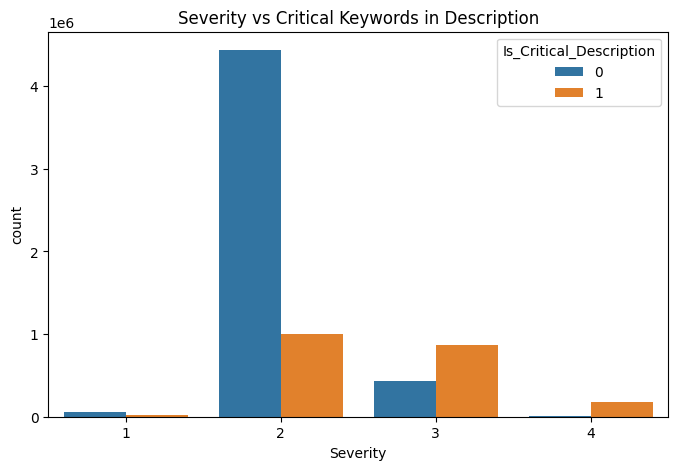

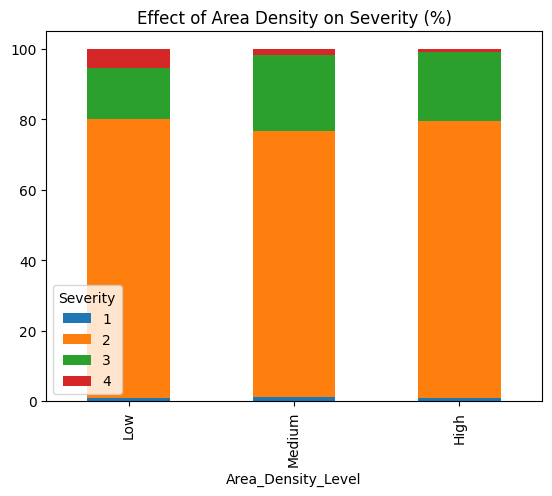

In [5]:
# ดูความสัมพันธ์ระหว่าง Critical Description กับ Severity
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Severity', hue='Is_Critical_Description')
plt.title('Severity vs Critical Keywords in Description')
plt.show()

# ตรวจสอบว่า Area_Density_Level มีผลต่อความรุนแรงอย่างไร
density_severity = pd.crosstab(df['Area_Density_Level'], df['Severity'], normalize='index') * 100
density_severity.plot(kind='bar', stacked=True)
plt.title('Effect of Area Density on Severity (%)')
plt.show()

Cell 6: Final Data Preparation & Saving
เลือกเฉพาะฟีเจอร์ที่จะเข้าโมเดล และจัดการ Categorical ให้เป็นตัวเลข

In [6]:
# เลือก Features ที่จะส่งไป Modeling
# หมายเหตุ: เราจะไม่เอาพิกัดดิบหรือ Description ยาวๆ เข้าโมเดลเพื่อประหยัด RAM
model_features = [
    'Severity', 'Log_Distance', 'Log_Duration', 'Hour_sin', 'Hour_cos', 
    'Month_sin', 'Month_cos', 'Is_Critical_Description', 'Area_Density_Level',
    'Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)', 
    'Precipitation(in)', 'Amenity', 'Crossing', 'Junction', 'Traffic_Signal'
]

df_model = df[model_features].copy()

# แปลง Density Level (Categorical) เป็นตัวเลข (One-Hot Encoding)
df_model = pd.get_dummies(df_model, columns=['Area_Density_Level'], drop_first=True)

# บันทึกไฟล์ที่พร้อมสำหรับการทำ Modeling
df_model.to_parquet("../data/processed/accidents_for_model.parquet", index=False)
print("ไฟล์ 03 เสร็จสิ้น: ข้อมูลพร้อมสำหรับการทำ Modeling ในไฟล์ 05 แล้ว!")

ไฟล์ 03 เสร็จสิ้น: ข้อมูลพร้อมสำหรับการทำ Modeling ในไฟล์ 05 แล้ว!


โค้ดเช็กความพร้อม (Pre-flight Check)

--- เริ่มการเช็กความพร้อมของฟีเจอร์ใหม่ ---


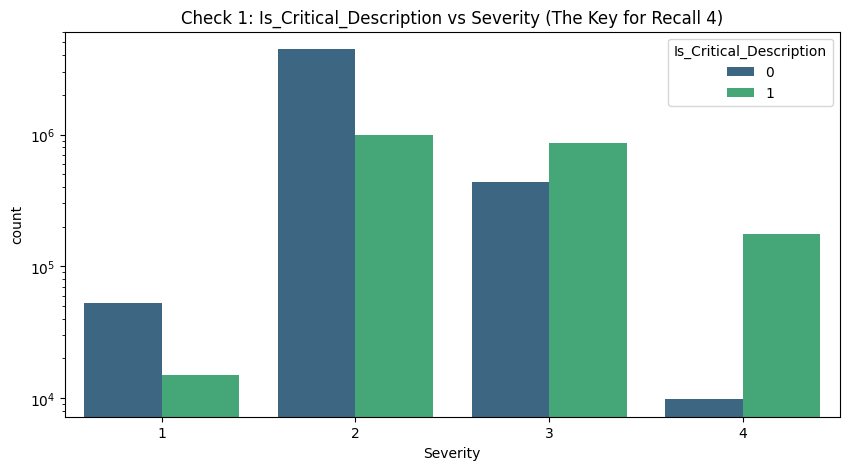

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23648\1180444089.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Severity', y='Log_Distance', palette='Set3')


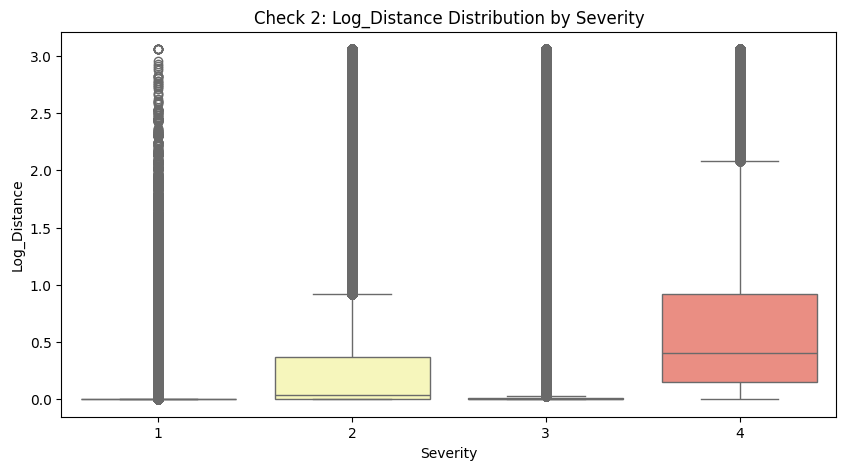


Check 3: Risk Table (%) by Area Density


Severity,1,2,3,4
Area_Density_Level,,,,
Low,0.89,79.18,14.60,5.33
Medium,1.15,75.56,21.64,1.64
High,0.85,78.63,19.56,0.96



--- สรุปรายชื่อ Features ที่จะนำไปใช้ในไฟล์ถัดไป ---
จำนวน Features ทั้งหมด: 18 คอลัมน์
['Severity', 'Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Amenity', 'Crossing', 'Junction', 'Traffic_Signal', 'Log_Distance', 'Log_Duration', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'Is_Critical_Description', 'Area_Density_Level']

✅ ทุกฟีเจอร์สะอาด 100% พร้อมไปไฟล์ 04 และ 05 แล้วครับ!


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- เริ่มการเช็กความพร้อมของฟีเจอร์ใหม่ ---")

# 1. เช็กความสัมพันธ์ของ Is_Critical_Description กับ Severity
# ถ้าฟีเจอร์นี้ดี เราควรเห็น Severity 4 มีสัดส่วนสีที่ต่างออกไปอย่างชัดเจน
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Severity', hue='Is_Critical_Description', palette='viridis')
plt.title('Check 1: Is_Critical_Description vs Severity (The Key for Recall 4)')
plt.yscale('log') # ใช้ Log scale เพราะ Severity 2 เยอะเกินไป จะได้เห็นคลาสอื่นชัดๆ
plt.show()

# 2. เช็กการกระจายตัวของ Log_Distance แยกตาม Severity
# อุบัติเหตุที่รุนแรง (Severity 4) มักส่งผลกระทบต่อระยะทางถนนที่ยาวกว่า
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Severity', y='Log_Distance', palette='Set3')
plt.title('Check 2: Log_Distance Distribution by Severity')
plt.show()

# 3. เช็กความสัมพันธ์ระหว่าง Area_Density_Level กับความรุนแรง
# เพื่อดูว่าพื้นที่หนาแน่นต่ำ (Low Density) เสี่ยงเกิด Severity สูงกว่าจริงหรือไม่
density_risk = pd.crosstab(df['Area_Density_Level'], df['Severity'], normalize='index') * 100
print("\nCheck 3: Risk Table (%) by Area Density")
display(density_severity.round(2))

# 4. สรุปรายชื่อ Features ที่พร้อมส่งออก
print("\n--- สรุปรายชื่อ Features ที่จะนำไปใช้ในไฟล์ถัดไป ---")
final_cols = [col for col in df.columns if col in model_features or 'Area_Density_Level' in col]
print(f"จำนวน Features ทั้งหมด: {len(final_cols)} คอลัมน์")
print(final_cols)

# 5. เช็ก Missing Value รอบสุดท้าย (ต้องเป็น 0)
if df[final_cols].isnull().sum().sum() == 0:
    print("\n✅ ทุกฟีเจอร์สะอาด 100% พร้อมไปไฟล์ 04 และ 05 แล้วครับ!")
else:
    print("\n❌ ยังมี Missing Value หลงเหลือในบางฟีเจอร์ กรุณาตรวจสอบอีกครั้ง")

In [9]:
# 1. ดูซิว่าตัวการคือคอลัมน์ไหน (Print ออกมาดู)
print("--- คอลัมน์ที่ยังมี Missing Value ---")
missing_cols = df[final_cols].isnull().sum()
print(missing_cols[missing_cols > 0])

--- คอลัมน์ที่ยังมี Missing Value ---
Series([], dtype: int64)
